In [25]:

import pandas as pd

btc = pd.read_csv("/Users/lizeyu/Desktop/qoc/tmp/raw/5m_klines_raw/BTCUSDT_klines_5m.csv")

# Update Close Time and Open Time columns if values are less than 2000000000000
btc['Close Time'] = btc['Close Time'].apply(lambda x: x * 1000+999 if x < 2000000000000 else x)
btc['Open Time'] = btc['Open Time'].apply(lambda x: x * 1000 if x < 2000000000000 else x)

In [26]:

# 将时间戳转换为 datetime 格式
btc['Close Time'] = pd.to_datetime(btc['Close Time'], unit='us')
btc['Open Time'] = pd.to_datetime(btc['Open Time'], unit='us')

# 设置索引
btc.set_index("Close Time", inplace=True)

In [27]:
btc = btc.loc['2024-01-01':'2025-07-01']


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置图形风格
plt.style.use("seaborn-v0_8")


In [29]:
deri_window = 3    # 12d
n=12*24*deri_window  # VWAP window in 5m
# threshold = 750    # $/d


In [30]:
cum_vol = btc["Volume"].rolling(window=n).sum()
cum_vol_px = (btc["Close"] * btc["Volume"]).rolling(window=n).sum()
btc["VWAP"] = cum_vol_px / cum_vol


In [31]:
# 计算 VWAP_derivative
shift_steps = deri_window * 24 * 12
btc["VWAP_derivative"] = (btc["VWAP"] - btc["VWAP"].shift(shift_steps))/deri_window
btc["VWAP_derivative2"] = (btc["VWAP_derivative"] - btc["VWAP_derivative"].shift(shift_steps))/deri_window

In [32]:
# 在所有子图上绘制贯穿的竖线并在正区域上色


In [33]:
# 在 VWAP_derivative 和 VWAP_derivative2 都小于0的区域上色


In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Plot Close and VWAP on the first subplot
ax1.plot(btc["Close"], label="Close", alpha=0.6)
ax1.plot(btc["VWAP"], label="VWAP", color="blue")
ax1.set_ylabel("Price")
ax1.set_title("VWAP and VWAP_derivative")
ax1.legend(loc="upper left")

# Plot VWAP_derivative on the second subplot
ax2.plot(btc["VWAP_derivative"], label="VWAP_derivative", color="orange")
ax2.set_ylabel("VWAP_derivative")
ax2.legend(loc="upper left")

# Plot VWAP_derivative2 on the third subplot
ax3.plot(btc["VWAP_derivative2"], label="VWAP_derivative2", color="red")
ax3.set_ylabel("VWAP_derivative2")
ax3.legend(loc="upper left")

# Set the x-axis label for the bottom subplot
ax3.set_xlabel("Time")

# 在 ax2 和 ax3 上绘制 y=0 的横线
ax2.axhline(0, color='gray', linestyle='--', linewidth=1, label='y=0')
ax3.axhline(0, color='gray', linestyle='--', linewidth=1, label='y=0')

# 找到 VWAP_derivative 和 VWAP_derivative2 与 y=0 的交点
cross_points_derivative = btc[btc["VWAP_derivative"] * btc["VWAP_derivative"].shift(1) < 0]
cross_points_derivative2 = btc[btc["VWAP_derivative2"] * btc["VWAP_derivative2"].shift(1) < 0]





for cross_time in cross_points_derivative.index:
  ax1.axvline(cross_time, color='orange', linestyle='--', linewidth=0.8, alpha=0.7)
  ax2.axvline(cross_time, color='orange', linestyle='--', linewidth=0.8, alpha=0.7)
  ax3.axvline(cross_time, color='orange', linestyle='--', linewidth=0.8, alpha=0.7)

for cross_time in cross_points_derivative2.index:
  ax1.axvline(cross_time, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
  ax2.axvline(cross_time, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
  ax3.axvline(cross_time, color='red', linestyle='--', linewidth=0.8, alpha=0.7)

# 在 VWAP_derivative 和 VWAP_derivative2 都大于0的区域上色
positive_region = (btc["VWAP_derivative"] > 0) & (btc["VWAP_derivative2"] > 0)
for start, end in zip(positive_region[positive_region].index[:-1], positive_region[positive_region].index[1:]):
  if (end - start).total_seconds() / 60 == 5:  # 确保连续区域
    ax1.axvspan(start, end, color='yellow', alpha=0.2)
    ax2.axvspan(start, end, color='yellow', alpha=0.2)
    ax3.axvspan(start, end, color='yellow', alpha=0.2)

positive_region = (btc["VWAP_derivative"] < 0) & (btc["VWAP_derivative2"] < 0)
for start, end in zip(positive_region[positive_region].index[:-1], positive_region[positive_region].index[1:]):
  if (end - start).total_seconds() / 60 == 5:  # 确保连续区域
    ax1.axvspan(start, end, color='blue', alpha=0.03)
    ax2.axvspan(start, end, color='blue', alpha=0.03)
    ax3.axvspan(start, end, color='blue', alpha=0.03)
# 显示更新后的图形
fig.canvas.draw()

plt.tight_layout()
plt.show()

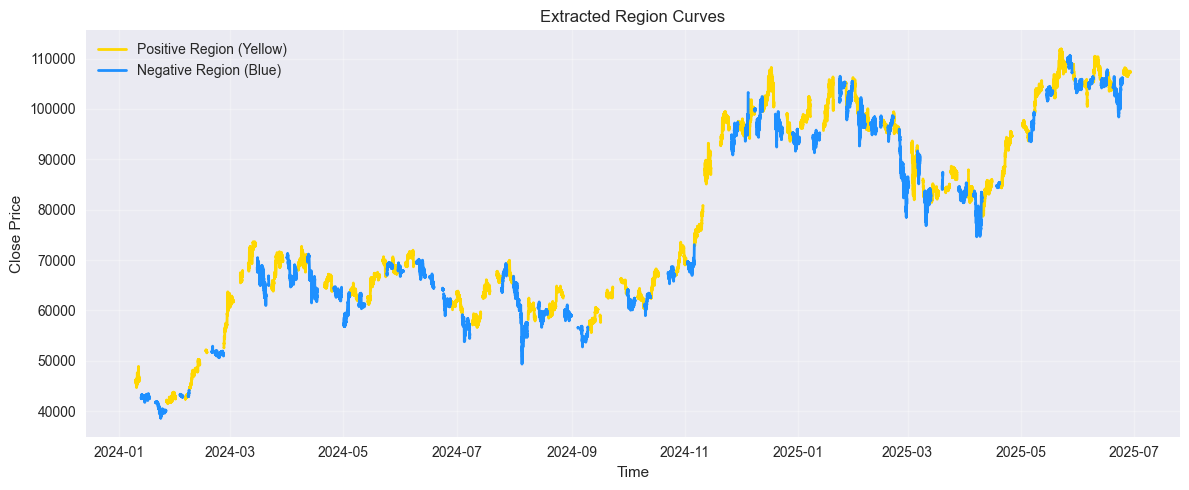

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== 假设 btc 是你的原始 DataFrame =====
# 这里示例直接用 btc 中的 VWAP_derivative 和 VWAP_derivative2

# 1️⃣ 定义黄色与蓝色区域的布尔掩码
mask_yellow = (btc["VWAP_derivative"] > 0) & (btc["VWAP_derivative2"] > 0)
mask_blue   = (btc["VWAP_derivative"] < 0) & (btc["VWAP_derivative2"] < 0)

# 2️⃣ 生成两条曲线（不满足条件的地方用 NaN 保持时间轴一致）
yellow_curve = np.where(mask_yellow, btc["Close"], np.nan)
blue_curve   = np.where(mask_blue,   btc["Close"], np.nan)

# 3️⃣ 新 figure 绘图
fig2, ax = plt.subplots(figsize=(12, 5))
ax.plot(btc.index, yellow_curve, color="gold",  lw=2, label="Positive Region (Yellow)")
ax.plot(btc.index, blue_curve,   color="dodgerblue", lw=2, label="Negative Region (Blue)")
ax.set_title("Extracted Region Curves")
ax.set_ylabel("Close Price")
ax.set_xlabel("Time")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [36]:
btc["pos"] = (btc["VWAP_derivative"] > 0) & (btc["VWAP_derivative2"] > 0)
btc["neg"]   = (btc["VWAP_derivative"] < 0) & (btc["VWAP_derivative2"] < 0)


Processing: 100%|██████████| 157824/157824 [00:00<00:00, 165644.88it/s]


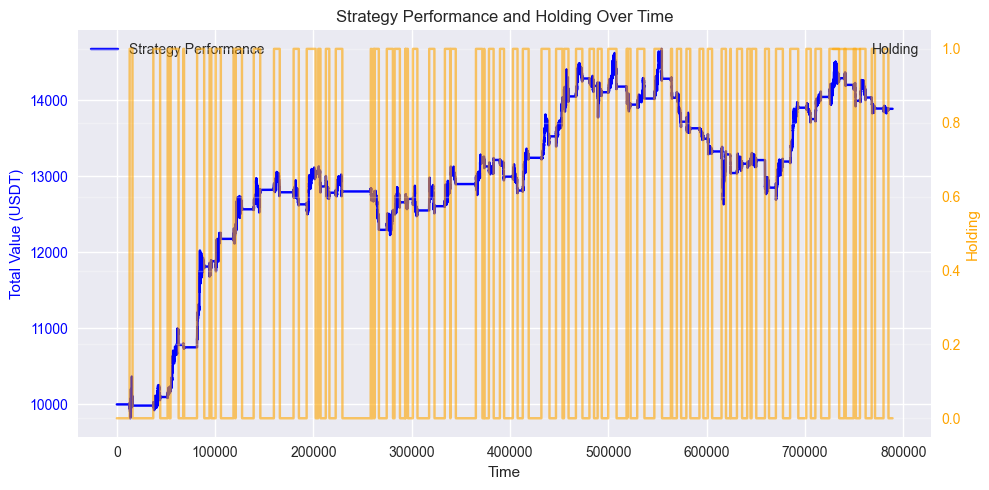

In [37]:
import numpy as np
import pandas as pd
from collections import deque
from tqdm import tqdm

def implement_strategy(
    btc: pd.DataFrame,
    trade_size: float,
    initial_cap: float = 10000.0,
    fee: float = 0.00,

):

    prices = btc["Close"].values
    n = len(prices)

    # 预分配结果
    total_value = np.zeros(n)
    holdings_array = np.zeros(n)
    pnl_records = np.zeros(n)  # 每次平仓的收益率记录

    # 策略状态
    capital = initial_cap     # USDT
    amount = 0.0              # 持仓BTC数量
    open_orders = deque()     # 存储未平仓订单 [{time, price, qty}]
    now_holding = 0

    for t in tqdm(range(n), desc="Processing"):
        price_t = prices[t]
        total_value[t] = capital + amount * price_t
        holdings_array[t] = now_holding

        # --- 买入信号 ---
        if (
            t >= 1 and btc['pos'].iloc[t-1]
            and now_holding==0
        ):
            qty = trade_size / price_t
            cost = trade_size * (1 + fee)

            if capital >= cost:  # 资金充足才买
                capital -= cost
                amount += qty
                now_holding += 1
                open_orders.append({"time": t, "price": price_t, "qty": qty})

        # # --- 卖空信号 ---
        # if (
        #     t >= 1 and btc['neg'].iloc[t-1]
        #     and now_holding==0
        # ):
        #     qty = trade_size / price_t
        #     cost = trade_size * (1 + fee)

        #     if capital >= cost:  # 资金充足才买
        #         capital += trade_size-trade_size * fee
        #         amount -= qty
        #         now_holding -= 1
        #         open_orders.append({"time": t, "price": price_t, "qty": qty})

        if not btc['pos'].iloc[t] and now_holding > 0:
            # 平多仓
            while open_orders and now_holding > 0:
                order = open_orders.popleft()
                sell_qty = order["qty"]
                sell_price = price_t
                proceeds = sell_qty * sell_price * (1 - fee)
                capital += proceeds
                amount -= sell_qty
                now_holding -= 1

                # 计算并记录收益率
                entry_price = order["price"]
                pnl = (sell_price - entry_price) / entry_price
                pnl_records[t] += pnl
        # if not btc['neg'].iloc[t] and now_holding < 0:
        #     # 平空仓
        #     while open_orders and now_holding < 0:
        #         order = open_orders.popleft()
        #         buy_qty = order["qty"]
        #         buy_price = price_t
        #         cost = buy_qty * buy_price * (1 + fee)
        #         capital -= cost
        #         amount += buy_qty
        #         now_holding += 1

        #         # 计算并记录收益率
        #         entry_price = order["price"]
        #         pnl = (entry_price - buy_price) / entry_price
        #         pnl_records[t] += pnl

    # 生成结果
    performance_df = pd.DataFrame(
        {"Total Value": total_value}, index=btc.index
    )
    holding_series = pd.Series(holdings_array, index=btc.index)
    pnl_series = pd.Series(pnl_records, index=btc.index)
    return performance_df, pnl_series, holding_series


# 运行优化后的策略
strategy_performance, pnls, holding = implement_strategy(
    btc,
    trade_size=6000

)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
ax1 = plt.gca()
ax2 = ax1.twinx()


x = [i * 5 for i in range(len(strategy_performance))]  # 每一行对应的分钟数



# 策略表现
ax1.plot(x, strategy_performance['Total Value'], label='Strategy Performance', color='blue')
ax1.set_ylabel('Total Value (USDT)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# 持仓
ax2.plot(x, holding.values, label='Holding', color='orange', alpha=0.6)
ax2.set_ylabel('Holding', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Strategy Performance and Holding Over Time')
ax1.set_xlabel('Time')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
# 筛选出 pnls 不等于 0 的值
non_zero_pnls = pnls[pnls != 0]

# 打印前几行以验证
print(non_zero_pnls.head())
# 将 pnls 转换为 numpy 数组以便计算
import numpy as np
pnls_array = np.array(non_zero_pnls)

# 计算基本统计指标
stats = {
    "总交易次数": len(pnls_array),
    "平均收益率": np.mean(pnls_array),
    "中位数收益率": np.median(pnls_array),
    "最大收益率": np.max(pnls_array),
    "最小收益率": np.min(pnls_array),
    "标准差": np.std(pnls_array),
    "正收益交易数": np.sum(pnls_array > 0),
    "负收益交易数": np.sum(pnls_array < 0),
    "胜率": np.mean(pnls_array > 0),
    "盈亏比": np.mean(pnls_array[pnls_array > 0]) / abs(np.mean(pnls_array[pnls_array < 0])) if np.any(pnls_array < 0) else float('inf'),
    "夏普比率": np.mean(pnls_array) / np.std(pnls_array) if np.std(pnls_array) > 0 else 0,
    "总收益率": np.sum(pnls_array)
}

# 打印统计指标
for key, value in stats.items():
    print(f"{key}: {value:.4f}" if isinstance(value, (float, np.float64)) else f"{key}: {value}")

Close Time
2024-01-12 01:29:59.999999   -0.002623
2024-01-31 14:19:59.999999    0.018775
2024-02-07 05:19:59.999999    0.012741
2024-02-13 14:24:59.999999    0.101455
2024-02-17 11:54:59.999999   -0.005273
dtype: float64
总交易次数: 66
平均收益率: 0.0098
中位数收益率: 0.0051
最大收益率: 0.1770
最小收益率: -0.0847
标准差: 0.0433
正收益交易数: 35
负收益交易数: 31
胜率: 0.5303
盈亏比: 1.6597
夏普比率: 0.2265
总收益率: 0.6477


In [57]:
strategy_performance.index

DatetimeIndex(['2024-01-01 00:04:59.999999', '2024-01-01 00:09:59.999999',
               '2024-01-01 00:14:59.999999', '2024-01-01 00:19:59.999999',
               '2024-01-01 00:24:59.999999', '2024-01-01 00:29:59.999999',
               '2024-01-01 00:34:59.999999', '2024-01-01 00:39:59.999999',
               '2024-01-01 00:44:59.999999', '2024-01-01 00:49:59.999999',
               ...
               '2025-07-01 23:14:59.999999', '2025-07-01 23:19:59.999999',
               '2025-07-01 23:24:59.999999', '2025-07-01 23:29:59.999999',
               '2025-07-01 23:34:59.999999', '2025-07-01 23:39:59.999999',
               '2025-07-01 23:44:59.999999', '2025-07-01 23:49:59.999999',
               '2025-07-01 23:54:59.999999', '2025-07-01 23:59:59.999999'],
              dtype='datetime64[ns]', name='Close Time', length=157824, freq=None)

In [ ]:
#

In [59]:
sp = pd.read_csv("/Users/lizeyu/Desktop/Quant-on-Crypto/examples/rev-strategy/sp.csv")
sp['Close Time'] = pd.to_datetime(sp['Close Time'])

In [60]:
sp.set_index("Close Time", inplace=True)

In [61]:
sp.index

DatetimeIndex(['2024-01-01 00:04:59.999999', '2024-01-01 00:09:59.999999',
               '2024-01-01 00:14:59.999999', '2024-01-01 00:19:59.999999',
               '2024-01-01 00:24:59.999999', '2024-01-01 00:29:59.999999',
               '2024-01-01 00:34:59.999999', '2024-01-01 00:39:59.999999',
               '2024-01-01 00:44:59.999999', '2024-01-01 00:49:59.999999',
               ...
               '2025-08-31 23:14:59.999999', '2025-08-31 23:19:59.999999',
               '2025-08-31 23:24:59.999999', '2025-08-31 23:29:59.999999',
               '2025-08-31 23:34:59.999999', '2025-08-31 23:39:59.999999',
               '2025-08-31 23:44:59.999999', '2025-08-31 23:49:59.999999',
               '2025-08-31 23:54:59.999999', '2025-08-31 23:59:59.999999'],
              dtype='datetime64[ns]', name='Close Time', length=175392, freq=None)

In [62]:
sp

,Total Value,Peak,Drawdown,Drawdown Start,Drawdown End
Close Time,,,,,
2024-01-01 00:04:59.999999,10000.000000,10000.000000,0.000000,False,False
2024-01-01 00:09:59.999999,10000.000000,10000.000000,0.000000,False,False
2024-01-01 00:14:59.999999,10000.000000,10000.000000,0.000000,False,False
2024-01-01 00:19:59.999999,10000.000000,10000.000000,0.000000,False,False
2024-01-01 00:24:59.999999,10000.000000,10000.000000,0.000000,False,False
...,...,...,...,...,...
2025-08-31 23:39:59.999999,12242.390275,12372.726216,-0.010534,False,False
2025-08-31 23:44:59.999999,12242.390275,12372.726216,-0.010534,False,False
2025-08-31 23:49:59.999999,12242.390275,12372.726216,-0.010534,False,False


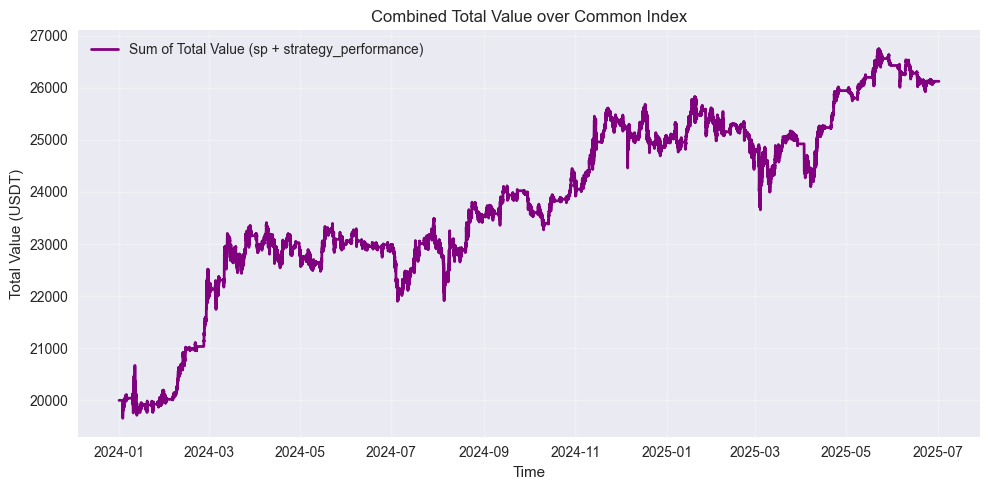

In [63]:
import matplotlib.pyplot as plt

# 1️⃣ 取时间索引交集并排序
common_index = sp.index.intersection(strategy_performance.index).sort_values()

# 2️⃣ 对齐后求和
total_sum = sp.loc[common_index, "Total Value"] + \
            strategy_performance.loc[common_index, "Total Value"]

# 3️⃣ 画图
plt.figure(figsize=(10,5))
plt.plot(common_index, total_sum, color="purple", lw=2,
         label="Sum of Total Value (sp + strategy_performance)")
plt.title("Combined Total Value over Common Index")
plt.xlabel("Time")
plt.ylabel("Total Value (USDT)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [64]:
common_index

DatetimeIndex(['2024-01-01 00:04:59.999999', '2024-01-01 00:09:59.999999',
               '2024-01-01 00:14:59.999999', '2024-01-01 00:19:59.999999',
               '2024-01-01 00:24:59.999999', '2024-01-01 00:29:59.999999',
               '2024-01-01 00:34:59.999999', '2024-01-01 00:39:59.999999',
               '2024-01-01 00:44:59.999999', '2024-01-01 00:49:59.999999',
               ...
               '2025-07-01 23:14:59.999999', '2025-07-01 23:19:59.999999',
               '2025-07-01 23:24:59.999999', '2025-07-01 23:29:59.999999',
               '2025-07-01 23:34:59.999999', '2025-07-01 23:39:59.999999',
               '2025-07-01 23:44:59.999999', '2025-07-01 23:49:59.999999',
               '2025-07-01 23:54:59.999999', '2025-07-01 23:59:59.999999'],
              dtype='datetime64[ns]', name='Close Time', length=157824, freq='5min')